# 03 · M1 — M0 on log returns instead of price changes

## Executive summary (read this first)

**The idea.** M0 assumes each day's **change** (`today − yesterday`) is normal, with the same size whatever the level.
For a price or a yield that is odd: a move of 0.10 means something different at a yield of 0.5 % than at 5 %. **M1**
assumes each day's **log return** `log(today ÷ yesterday)` is normal instead, so a move scales with the level and the
forecast can never go below zero.

**M1 is M0 with one change**, nothing else:

| | M0 | M1 |
|---|---|---|
| step (level unit) | today − yesterday | log(today ÷ yesterday) |
| forecast at h | last + h × mu + noise | last × exp(h × mu + noise) |
| history, gap rule, one path across horizons, covariance, seed, 500 draws | same | same |

- On a **log-return unit** (23 of the 103 units: the series already is a return) M1 is exactly M0.
- If a level series has a value ≤ 0 in its 300 rows (none of the visible units does), M1 uses M0's change for it.
- Because M1 uses the same random numbers as M0, the difference between their scores is the model, not luck.

**The test.** The same backtest dates and answers as notebook 01 (latest 30 % of each unit, every 5th date). The
competition score per unit = `Σ weight × mean(M1's category score) ÷ mean(M0's)`: below 1, M1 beats M0.

Results: §5 (per unit), §6 (per family), §8 (in short). No realized outcome is read.

## 0 — Setup: notebook 01's backtest dates, answers and M0 scores

In [1]:
import bisect, multiprocessing as mp, pathlib, sys, time, tomllib, warnings, zlib
import numpy as np, pandas as pd, pyarrow.parquet as pq
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_experiment_v3" else pathlib.Path.cwd() / "model_experiment_v3"
REPO, UNITS, DATA = HERE.parent, HERE.parent / "units", HERE / "data"
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
import m0_baseline as m0
from qfbench2_track_forecasting import scoring as S
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 30); pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
WORKERS = max(1, (mp.cpu_count() or 2) - 2)
geo = lambda r: float(np.exp(np.log(np.asarray(r, float)).mean()))

ANSWERS = pd.read_parquet(DATA / "backtest_answers.parquet")
M0_SCORES = pd.read_parquet(DATA / "m0_backtest_scores.parquet")
UNIT_IDS = sorted(ANSWERS.unit.unique())
print(f"{len(UNIT_IDS)} units, {M0_SCORES.shape[0]:,} backtest dates (from notebook 01)")

103 units, 23,635 backtest dates (from notebook 01)


In [2]:
def load_unit(u):
    """Card fields and each asset's history up to the as-of, read with M0's rule (first panel holding the asset)."""
    ud = UNITS / u
    card = tomllib.loads((ud / "card.toml").read_text()); t = card["targets"]
    assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    uid, asof = card["task"]["id"], card["provenance"]["data_cutoff"]
    rows = {}
    for a in assets:
        for path in sorted(ud.glob("*.parquet")):
            tab = pq.read_table(path).to_pydict()
            acol = "asset" if "asset" in tab else ("asset_id" if "asset_id" in tab else None)
            if acol is None:
                continue
            r = sorted((str(d)[:10], float(v)) for d, x, v in zip(tab["date"], tab[acol], tab["value"])
                       if str(x) == a and str(d)[:10] <= asof and v is not None)
            if r:
                rows[a] = r; break
    return {"unit": u, "id": uid, "family": card["metadata"]["category"], "card": card, "assets": assets,
            "horizons": horizons, "target_type": t.get("target_type", "level"), "asof": asof, "rows": rows,
            "dates": {a: [d for d, _ in rows[a]] for a in assets},
            "steps": {h: m0._MONTHLY_STEPS.get(uid, {}).get(h, h) for h in horizons}}

UNITS_DATA = {u: load_unit(u) for u in UNIT_IDS}
DATES = {}
for u, g in ANSWERS.groupby("unit"):
    U = UNITS_DATA[u]
    order = {(a, h): i for i, (a, h) in enumerate((a, h) for a in U["assets"] for h in U["horizons"])}
    DATES[u] = [(o, gg.assign(i=[order[(a, h)] for a, h in zip(gg.asset, gg.horizon)]).sort_values("i").answer.to_numpy())
                for o, gg in g.groupby("origin")]
kinds = pd.Series({u: U["target_type"] for u, U in UNITS_DATA.items()}).value_counts()
print("units by target type:", kinds.to_dict(), "-> M1 differs from M0 only on the level units")

units by target type: {'level': 87, 'log_return': 16} -> M1 differs from M0 only on the level units


## 1 — M1 by hand on one unit (the same as notebook 02)

`t2-F1-greater-confidence-2024`: UST_2Y, as of 2024-01-31, horizons 126 and 189. The same 300 rows as M0; the steps
are now log returns.

In [3]:
U = UNITS_DATA["t2-F1-greater-confidence-2024"]; a = U["assets"][0]; h1, h2 = U["horizons"]
rows = U["rows"][a][-300:]
v = np.array([x for _, x in rows]); last = v[-1]
chg, logret = np.diff(v), np.diff(np.log(v))                     # (the gap rule drops nothing on this daily panel)
mu0, s0 = chg.mean(), np.sqrt(np.cov(chg))
mu1, s1 = logret.mean(), np.sqrt(np.cov(logret))
print(f"last value {last}")
print(f"M0: change      mean {mu0:+.6f}, sd {s0:.6f}  (percentage points per day)")
print(f"M1: log return  mean {mu1:+.6f}, sd {s1:.6f}  (= {100 * s1:.2f} % of the level per day)")
for h in (h1, h2):
    print(f"\nh = {h}:")
    print(f"  M0  centre = {last} + {h} x ({mu0:+.6f}) = {last + h * mu0:.4f},  sd = {s0:.4f} x sqrt({h}) = {s0 * np.sqrt(h):.4f}")
    print(f"  M1  median = {last} x exp({h} x ({mu1:+.6f})) = {last * np.exp(h * mu1):.4f},  "
          f"log sd = {s1:.5f} x sqrt({h}) = {s1 * np.sqrt(h):.4f}  ->  "
          f"68 % range {last * np.exp(h * mu1 - s1 * np.sqrt(h)):.3f} to {last * np.exp(h * mu1 + s1 * np.sqrt(h)):.3f}")

last value 4.27
M0: change      mean -0.000803, sd 0.091432  (percentage points per day)
M1: log return  mean -0.000183, sd 0.021103  (= 2.11 % of the level per day)

h = 126:
  M0  centre = 4.27 + 126 x (-0.000803) = 4.1689,  sd = 0.0914 x sqrt(126) = 1.0263
  M1  median = 4.27 x exp(126 x (-0.000183)) = 4.1727,  log sd = 0.02110 x sqrt(126) = 0.2369  ->  68 % range 3.293 to 5.288

h = 189:
  M0  centre = 4.27 + 189 x (-0.000803) = 4.1183,  sd = 0.0914 x sqrt(189) = 1.2570
  M1  median = 4.27 x exp(189 x (-0.000183)) = 4.1249,  log sd = 0.02110 x sqrt(189) = 0.2901  ->  68 % range 3.086 to 5.513


## 2 — M1 at any date

The same code as M0 (notebook 01's `m0_draws`), with the level steps taken on `log(value)`: `m0._steps` on the log values
gives exactly the log returns, with the same gap rule. The draws come out in log space and are turned back with
`last × exp(·)`. Checks: on the 23 log-return units M1 equals M0 exactly; on a level unit it is the lognormal version.

log-return units (16): max |M1 - M0| at the real as-of = 0.0e+00


,1%,5%,25%,50%,75%,95%,99%
M0 h=126,1.909,2.58,3.449,4.105,4.829,6.037,6.784
M1 h=126,2.477,2.892,3.534,4.111,4.859,6.423,7.63
M0 h=189,1.239,2.094,3.171,4.157,4.935,6.149,6.969
M1 h=189,2.122,2.585,3.315,4.162,4.981,6.591,7.964


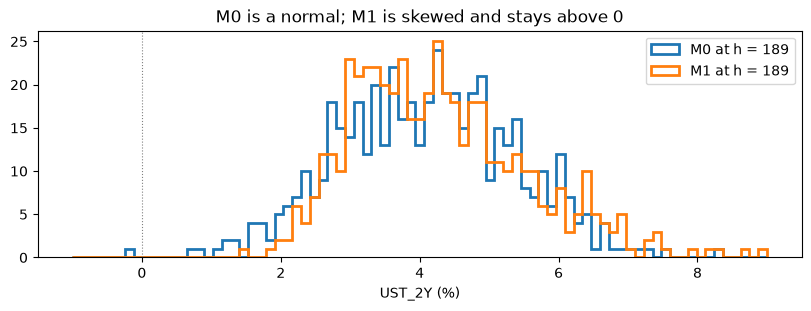

In [4]:
def m1_draws(U, origin):
    """M1's 500 draws at `origin`, shape (500, n_assets, n_horizons), card order."""
    assets, horizons, tt = U["assets"], U["horizons"], U["target_type"]
    by_asset = sorted(assets)
    steps, last, log_mode = {}, {}, {}
    for a in by_asset:
        k = bisect.bisect_right(U["dates"][a], origin)
        rows = U["rows"][a][max(0, k - m0._WINDOW): k]
        log_mode[a] = tt == "level" and min(x for _, x in rows) > 0
        if log_mode[a]:                                          # M1: steps on log(value) = log returns
            steps[a], _ = m0._steps([(d, np.log(x)) for d, x in rows], "level")
            last[a] = rows[-1][1]
        else:                                                    # a log-return unit, or a value <= 0: M0's step
            steps[a], lv = m0._steps(rows, tt)
            last[a] = lv if tt == "level" else 0.0
    common = sorted(set.intersection(*(set(steps[a]) for a in by_asset)))
    x = np.array([[steps[a][d] for d in common] for a in by_asset])
    mu, sigma = x.mean(axis=1), np.atleast_2d(np.cov(x))
    ai = {a: i for i, a in enumerate(by_asset)}
    cells = [(a, h) for a in by_asset for h in sorted(horizons)]
    s = U["steps"]
    mean = np.array([(0.0 if log_mode[a] else last[a]) + s[h] * mu[ai[a]] for a, h in cells])
    cov = np.array([[min(s[h1], s[h2]) * sigma[ai[a1], ai[a2]] for a2, h2 in cells] for a1, h1 in cells])
    cov[np.diag_indices_from(cov)] += 1e-10
    jittered = cov + 1e-9 * np.eye(len(cells))
    try:
        factor = np.linalg.cholesky(jittered)
    except np.linalg.LinAlgError:
        factor = np.diag(np.sqrt(np.diag(jittered)))
    rng = np.random.default_rng(zlib.crc32(U["id"].encode()) & 0x7FFFFFFF)      # M0's seed: the same random numbers
    samples = mean + rng.standard_normal((m0.N_DRAWS, len(cells))) @ factor.T
    out = np.empty((m0.N_DRAWS, len(assets), len(horizons)))
    for ci, (a, h) in enumerate(cells):
        out[:, assets.index(a), horizons.index(h)] = last[a] * np.exp(samples[:, ci]) if log_mode[a] else samples[:, ci]
    return out

lr = [u for u, U in UNITS_DATA.items() if U["target_type"] == "log_return"]
d = max(float(np.abs(m1_draws(UNITS_DATA[u], UNITS_DATA[u]["asof"]) - m0.draws(UNITS / u)).max()) for u in lr)
print(f"log-return units ({len(lr)}): max |M1 - M0| at the real as-of = {d:.1e}")
assert d == 0

U = UNITS_DATA["t2-F1-greater-confidence-2024"]
both = {"M0": m0.draws(UNITS / U["unit"])[:, 0, :], "M1": m1_draws(U, U["asof"])[:, 0, :]}
q = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
display(pd.DataFrame({f"{m} h={h}": np.quantile(both[m][:, i], q) for i, h in enumerate(U["horizons"]) for m in both},
                     index=[f"{int(p * 100)}%" for p in q]).T)
fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
bins = np.linspace(-1, 9, 80)
for m, col in (("M0", "tab:blue"), ("M1", "tab:orange")):
    ax.hist(both[m][:, 1], bins=bins, histtype="step", lw=2, color=col, label=f"{m} at h = {U['horizons'][1]}")
ax.axvline(0, color="grey", lw=.8, ls=":"); ax.set_xlabel("UST_2Y (%)"); ax.legend(); ax.set_title("M0 is a normal; M1 is skewed and stays above 0")
plt.show()

## 3 — Score M1 at every backtest date

The same dates and answers as notebook 01, scored with the same official categories.

In [5]:
def parts(card, samples, y):
    p = card.get("scoring", {}).get("params", {})
    return S._composite(samples, y, weights=m0.card_weights(card, samples.shape[1]),
                        tail_levels=tuple(p.get("tail_levels", (0.01, 0.05, 0.95, 0.99))), joint=S.card_joint_statistic(card),
                        tail_metric=str(p.get("tail_metric", S.DEFAULT_TAIL_METRIC)), ref_scale=None)

def score_unit(u):
    U = UNITS_DATA[u]
    return [{"unit": u, "family": U["family"], "origin": o, **parts(U["card"], m1_draws(U, o).reshape(m0.N_DRAWS, -1), y)}
            for o, y in DATES[u]]

t0 = time.time()
with mp.get_context("fork").Pool(WORKERS) as pool:
    M1_SCORES = pd.DataFrame([r for rows in pool.map(score_unit, UNIT_IDS, chunksize=1) for r in rows])
assert len(M1_SCORES) == len(M0_SCORES)
print(f"scored M1 on {len(M1_SCORES):,} dates in {time.time() - t0:.0f}s")

scored M1 on 23,635 dates in 1s


## 4 — The competition score

Per unit, over its backtest dates: `score = w_CRPS × mean(CRPS_M1) ÷ mean(CRPS_M0) + w_var × mean(var_M1) ÷ mean(var_M0)
+ w_tail × mean(tail_M1) ÷ mean(tail_M0)`. M0 = 1.0; below 1, M1 is better.

In [6]:
cats = {"marginal": "CRPS", "joint": "variogram", "tail": "tail"}
mean1 = M1_SCORES.groupby("unit")[["marginal", "joint", "tail", "composite"]].mean()
mean0 = M0_SCORES.groupby("unit")[["marginal", "joint", "tail", "composite"]].mean()
rows = []
for u in UNIT_IDS:
    U = UNITS_DATA[u]; w = m0.card_weights(U["card"], len(U["assets"]) * len(U["horizons"]))
    r = {"family": U["family"], "unit": u, "target": U["target_type"], "dates": int((M1_SCORES.unit == u).sum())}
    for (k, name), wk in zip(cats.items(), w):
        r[f"M1 {name}"] = mean1.loc[u, k]
        r[f"{name} ÷ M0"] = mean1.loc[u, k] / mean0.loc[u, k] if wk else np.nan
    r["M1 weighted sum"], r["M0 weighted sum"] = mean1.loc[u, "composite"], mean0.loc[u, "composite"]
    r["score vs M0"] = sum(wk * mean1.loc[u, k] / mean0.loc[u, k] for k, wk in zip(cats, w) if wk)
    rows.append(r)
RESULT = pd.DataFrame(rows).set_index(["family", "unit"])

## 5 — Per unit

In [7]:
print("M1 per unit: mean score per category, each ÷ M0's, weighted sums, and the competition score vs M0 (below 1 = M1 better)")
RESULT

M1 per unit: mean score per category, each ÷ M0's, weighted sums, and the competition score vs M0 (below 1 = M1 better)


target  dates  M1 CRPS  CRPS ÷ M0  M1 variogram  variogram ÷ M0   M1 tail  tail ÷ M0  M1 weighted sum  M0 weighted sum  score vs M0
family unit                                                                                                                                                                      
T2-F1  t2-F1-ai-mom-2024                  log_return    355  0.06966          1             0             NaN  0.007328          1          0.05185          0.05185            1
       t2-F1-aud-on-hold-2016                  level    237  0.05322     0.9879       0.01416          0.9953  0.006057      1.015          0.03207           0.0324       0.9955
       t2-F1-cad-boc-2017                      level    247  0.04673      1.037       0.01747           1.015   0.00627      0.982          0.02986          0.02896         1.02
       t2-F1-chf-highly-valued-2021            level    306  0.02777      1.022       0.01207           1.063  0.004045      1.037          0.01831          0.01777        1.037
       t2-F1-conflicting-texts-2024            level    350   0.5391      1.117        0.2141           1.661   0.08323      1.189           0.3504           0.2939        1.295
       t2-F1-considerable-period-2003          level     37    0.532     0.9699        0.1299          0.9428   0.05548      1.019           0.3161           0.3265       0.9716
       t2-F1-conundrum-2005                    level     60   0.4624      0.923        0.1192           0.935   0.06114     0.9953           0.2792            0.301       0.9411
       t2-F1-cpi-glidepath-2023                level     11    4.307     0.9035        0.3211          0.8157     1.231     0.7765            2.496            2.819       0.8517
       t2-F1-dkk-peg-2019                      level    275   0.3325      1.016             0             NaN   0.05082     0.9816            0.252           0.2487        1.006
       t2-F1-eur-range-2017                    level    250  0.06852     0.9623       0.01476          0.8999   0.01065      1.008          0.04082          0.04264       0.9528
       t2-F1-fed-put-2019                 log_return    280  0.04127          1             0             NaN  0.005081          1          0.03093          0.03093            1
       t2-F1-greater-confidence-2024           level    345    1.766      2.378         2.257           8.275    0.3039       1.76            1.621           0.4876        4.024
       t2-F1-hawkish-cut-2024                  level    358    1.906      2.436         2.449           8.954    0.3086      1.755            1.749           0.5083        4.255
       t2-F1-jpy-ycc-flex-2018                 level    263    8.214      1.034         1.663           1.054     1.318      1.004            4.869            4.707        1.034
       t2-F1-liftoff-telegraph-2015            level    221   0.1085     0.9855       0.08331           1.229   0.02034      1.284          0.08329          0.07852        1.118
       t2-F1-measured-pace-2004                level     51   0.4263     0.6715        0.1211          0.7278   0.04204     0.6744           0.2579           0.3798       0.6889
       t2-F1-normalization-2017                level    249   0.3735     0.9976             0             NaN    0.0371      1.071           0.2774           0.2773        1.019
       t2-F1-patient-dropped-2015              level    215   0.1062     0.9064             0             NaN   0.01821      1.134          0.08106          0.08828       0.9714
       t2-F1-pause-2006                        level     82   0.3975       1.28         2.531           1.912   0.05859      1.512           0.9698           0.5601        1.516
       t2-F1-qe3-end-2014                      level    206    0.545     0.9865        0.1569           1.154   0.05373      1.036           0.3303           0.3274        1.047
       t2-F1-sahm-watch-2024                   level     12    1.741     0.9597         1.611          0.9823    0.5469     0.9278

In [8]:
lv = RESULT[RESULT.target == "level"]
print("level units, best 8 for M1:"); display(lv.nsmallest(8, "score vs M0")[["dates", "CRPS ÷ M0", "variogram ÷ M0", "tail ÷ M0", "score vs M0"]])
print("level units, worst 8 for M1:"); display(lv.nlargest(8, "score vs M0")[["dates", "CRPS ÷ M0", "variogram ÷ M0", "tail ÷ M0", "score vs M0"]])

level units, best 8 for M1:


dates  CRPS ÷ M0  variogram ÷ M0  tail ÷ M0  score vs M0
family unit                                                                                     
T2-F1  t2-F1-measured-pace-2004            51     0.6715          0.7278     0.6744       0.6889
T2-F2  t2-F2-considerable-removal-2004     52     0.7824             NaN     0.8399       0.7988
T2-F1  t2-F1-cpi-glidepath-2023            11     0.9035          0.8157     0.7765       0.8517
T2-F4  t2-F4-cpi-vintage-2022              10     0.9499             NaN     0.7528       0.8936
       t2-F4-cpi-friday-2022              330      0.935             NaN     0.9229       0.9315
T2-F1  t2-F1-conundrum-2005                60      0.923           0.935     0.9953       0.9411
T2-F3  t2-F3-taper-steepener-2013         188     0.9384          0.9059      1.032       0.9473
T2-F1  t2-F1-eur-range-2017               250     0.9623          0.8999      1.008       0.9528

level units, worst 8 for M1:


dates  CRPS ÷ M0  variogram ÷ M0  tail ÷ M0  score vs M0
family unit                                                                                       
T2-F1  t2-F1-hawkish-cut-2024               358      2.436           8.954      1.755        4.255
       t2-F1-greater-confidence-2024        345      2.378           8.275       1.76        4.024
T2-F2  t2-F2-cut-sizing-2024                361      1.243           5.076      1.222        2.389
T2-F1  t2-F1-third-cut-2019                 281      1.309           2.107      1.416        1.569
       t2-F1-pause-2006                      82       1.28           1.912      1.512        1.516
T2-F3  t2-F3-term-premium-steepener-2023    347      1.138           2.097      1.162         1.43
T2-F2  t2-F2-powell-pivot-2019              273       1.24             NaN      1.699        1.371
       t2-F2-time-has-come-2024             361      1.428             NaN      1.115        1.339

## 6 — Per family

The mean of the competition score over the family's units (as on the leaderboard), with the level units alone next to it
(on the log-return units M1 is M0, so they sit at exactly 1.0).

In [9]:
def fam_row(g):
    l = g[g.target == "level"]
    return {"units": len(g), "score vs M0 (mean)": g["score vs M0"].mean(), "median": g["score vs M0"].median(),
            "level units": len(l), "level units: mean": l["score vs M0"].mean() if len(l) else np.nan,
            "level units better": f'{(l["score vs M0"] < 1).sum()}/{len(l)}',
            "CRPS ÷ M0 (geo, level)": geo(l["CRPS ÷ M0"]) if len(l) else np.nan,
            "tail ÷ M0 (geo, level)": geo(l["tail ÷ M0"]) if len(l) else np.nan}
FAMILY = pd.DataFrame({f: fam_row(g) for f, g in [*RESULT.groupby("family"), ("all", RESULT)]}).T.rename_axis("family")
FAMILY

,units,score vs M0 (mean),median,level units,level units: mean,level units better,"CRPS ÷ M0 (geo, level)","tail ÷ M0 (geo, level)"
family,,,,,,,,
T2-F1,23,1.324,1.019,21,1.355,8/21,1.085,1.099
T2-F2,27,1.096,1,27,1.096,12/27,1.038,1.063
T2-F3,22,1.034,1,19,1.039,10/19,1.014,1.038
T2-F4,31,1.016,1,20,1.025,6/20,1.005,1.062
all,103,1.11,1,87,1.13,36/87,1.036,1.066


**By asset type** (level units only). A unit counts as one type when all its assets are of that type: **rates**
(US Treasury yields), **FX** (exchange rates), **macro** (CPI, payrolls, unemployment rate); otherwise **mixed**.

In [10]:
def asset_type(a):
    return "rates" if a.startswith("UST_") else "macro" if a in ("CPI_ALL", "NFP", "UNRATE") else "FX"
RESULT["type"] = [(lambda ts: ts.pop() if len(ts) == 1 else "mixed")({asset_type(a) for a in UNITS_DATA[u]["assets"]})
                  for u in RESULT.index.get_level_values("unit")]
lv = RESULT[RESULT.target == "level"]
BY_TYPE = pd.DataFrame({t: {"units": len(g), "score vs M0 (mean)": g["score vs M0"].mean(), "median": g["score vs M0"].median(),
                            "M1 better": f'{(g["score vs M0"] < 1).sum()}/{len(g)}',
                            "CRPS ÷ M0 (geo)": geo(g["CRPS ÷ M0"]), "tail ÷ M0 (geo)": geo(g["tail ÷ M0"])}
                        for t, g in lv.groupby("type")}).T.rename_axis("asset type")
BY_TYPE

,units,score vs M0 (mean),median,M1 better,CRPS ÷ M0 (geo),tail ÷ M0 (geo)
asset type,,,,,,
FX,35,1.001,0.9991,19/35,1.005,0.9895
macro,4,0.9295,0.9268,3/4,0.9473,0.8788
mixed,5,1.018,0.9998,3/5,1.007,0.9883
rates,43,1.266,1.071,11/43,1.075,1.163


## 7 — Save

In [11]:
M1_SCORES.to_parquet(DATA / "m1_backtest_scores.parquet", index=False)
RESULT.to_csv(DATA / "m1_vs_m0_per_unit.csv")
BY_TYPE.to_csv(DATA / "m1_vs_m0_by_asset_type.csv")
FAMILY.to_csv(DATA / "m1_vs_m0_per_family.csv")
for f in ("m1_backtest_scores.parquet", "m1_vs_m0_per_unit.csv", "m1_vs_m0_per_family.csv"):
    print(f"data/{f:<28} {(DATA / f).stat().st_size / 1e3:8.1f} kB")

data/m1_backtest_scores.parquet      867.1 kB
data/m1_vs_m0_per_unit.csv            20.1 kB
data/m1_vs_m0_per_family.csv           0.7 kB


## 8 — In short

In [12]:
a = FAMILY.loc["all"]
print(f"M1 vs M0 on {len(M1_SCORES):,} backtest dates: competition score {a['score vs M0 (mean)']:.4f} over all {int(a['units'])} units "
      f"(1.0 = M0, lower is better).")
print(f"On the {int(a['level units'])} level units, where M1 differs: mean {a['level units: mean']:.4f}, "
      f"M1 better on {a['level units better']}.")
for f in [f for f in FAMILY.index if f != "all"]:
    r = FAMILY.loc[f]
    print(f"  {f}: {r['score vs M0 (mean)']:.4f}  (level units {r['level units: mean']:.4f}, {r['level units better']} better)")
print("by asset type (level units): " + "; ".join(f"{t} {r['score vs M0 (mean)']:.3f} ({r['M1 better']} better)" for t, r in BY_TYPE.iterrows()))
print("-> " + ("log returns beat price changes." if a["score vs M0 (mean)"] < 0.99 else
               "log returns and price changes score within 1%: no real difference." if a["score vs M0 (mean)"] < 1.01 else
               "price changes (M0) beat log returns."))

M1 vs M0 on 23,635 backtest dates: competition score 1.1095 over all 103 units (1.0 = M0, lower is better).
On the 87 level units, where M1 differs: mean 1.1297, M1 better on 36/87.
  T2-F1: 1.3240  (level units 1.3548, 8/21 better)
  T2-F2: 1.0960  (level units 1.0960, 12/27 better)
  T2-F3: 1.0340  (level units 1.0394, 10/19 better)
  T2-F4: 1.0159  (level units 1.0246, 6/20 better)
by asset type (level units): FX 1.001 (19/35 better); macro 0.929 (3/4 better); mixed 1.018 (3/5 better); rates 1.266 (11/43 better)
-> price changes (M0) beat log returns.
